# Computer Vision Problem
- Image Classification
- Object Detection
- Neural Style Transfer
- Face Recognition

In [1]:
import numpy as np

## Detectar edges com covolução

In [2]:
## imagem preto e branco

matriz = [
    [3, 0, 1, 2, 7, 4],
    [1, 5, 8, 9, 3, 1],
    [2, 7, 2, 5, 1, 3],
    [0, 1, 3, 1, 7, 8],
    [4, 2, 1, 6, 2, 8],
    [2, 4, 5, 2, 3, 9]
]
matriz = np.array(matriz, dtype=np.float32)

In [3]:
filtro = [
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
]
filtro = np.array(filtro, dtype=np.float32)

In [4]:
np.sum(matriz[0:3, 1:4] * filtro)

np.float32(-4.0)

In [5]:
def conv2d_valid_loop(matriz: np.ndarray, filtro: np.ndarray) -> np.ndarray:
    H, W = matriz.shape
    kH, kW = filtro.shape
    outH, outW = H - kH + 1, W - kW + 1
    out = np.empty((outH, outW), dtype=np.float32)

    for i in range(outH):
        for j in range(outW):
            janela = matriz[i:i+kH, j:j+kW]
            out[i, j] = np.sum(janela * filtro)
    return out

In [6]:
conv2d_valid_loop(matriz, filtro)

array([[ -5.,  -4.,   0.,   8.],
       [-10.,  -2.,   2.,   3.],
       [  0.,  -2.,  -4.,  -7.],
       [ -3.,  -2.,  -3., -16.]], dtype=float32)

## Filtros

In [7]:
matriz = [
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
    [0, 0, 0, 10, 10, 10],
    [0, 0, 0, 10, 10, 10],
    [0, 0, 0, 10, 10, 10]
]
matriz = np.array(matriz, dtype=np.float32)

filtro_vertical = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
    ], dtype=np.float32)

In [8]:
conv2d_valid_loop(matriz, filtro_vertical)

array([[  0.,  30.,  30.,   0.],
       [  0.,  10.,  10.,   0.],
       [  0., -10., -10.,   0.],
       [  0., -30., -30.,   0.]], dtype=float32)

In [9]:
filtro_horizontal = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
    ], dtype=np.float32)

In [10]:
conv2d_valid_loop(matriz, filtro_horizontal)

array([[  0.,   0.,   0.,   0.],
       [-30., -10.,  10.,  30.],
       [-30., -10.,  10.,  30.],
       [  0.,   0.,   0.,   0.]], dtype=float32)

In [11]:
filtro_sobel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
    ], dtype=np.float32)

In [12]:
filtro_scharr = np.array([
    [3, 0, -3],
    [10, 0, -10],
    [3, 0, -3]
    ], dtype=np.float32)

In [13]:
W1, W2, W3, W4, W5, W6, W7, W8, W9 = np.zeros(9)

filtro_backprop = np.array([
    [W1, W2, W3],
    [W4, W5, W6],
    [W7, W8, W9]
    ], dtype=np.float32)

# O próprio algortimo irá aprender os pesos do filtro com backpropagation (derivadas parciais)

## Padding 

In [14]:
## original matrix

matriz

array([[10., 10., 10.,  0.,  0.,  0.],
       [10., 10., 10.,  0.,  0.,  0.],
       [10., 10., 10.,  0.,  0.,  0.],
       [ 0.,  0.,  0., 10., 10., 10.],
       [ 0.,  0.,  0., 10., 10., 10.],
       [ 0.,  0.,  0., 10., 10., 10.]], dtype=float32)

In [15]:
x, y = matriz.shape

padding = 1
x_new = x + 2*padding
y_new = y + 2*padding 

matriz_padding = np.zeros((x_new, y_new))
matriz_padding[padding:padding + x, padding:padding + y] = matriz
matriz_padding

array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0., 10., 10., 10.,  0.,  0.,  0.,  0.],
       [ 0., 10., 10., 10.,  0.,  0.,  0.,  0.],
       [ 0., 10., 10., 10.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0., 10., 10., 10.,  0.],
       [ 0.,  0.,  0.,  0., 10., 10., 10.,  0.],
       [ 0.,  0.,  0.,  0., 10., 10., 10.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]])

In [16]:
# identidade

filtro = [
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
]
filtro = np.array(filtro, dtype=np.float32)

In [17]:
# volto com a mesma matriz original

conv2d_valid_loop(matriz_padding, filtro)

array([[10., 10., 10.,  0.,  0.,  0.],
       [10., 10., 10.,  0.,  0.,  0.],
       [10., 10., 10.,  0.,  0.,  0.],
       [ 0.,  0.,  0., 10., 10., 10.],
       [ 0.,  0.,  0., 10., 10., 10.],
       [ 0.,  0.,  0., 10., 10., 10.]], dtype=float32)

## Strided Convolutions

In [18]:
def conv2d_stride(matriz: np.ndarray, filtro: np.ndarray, stride: int = 2) -> np.ndarray:
    H, W = matriz.shape
    kH, kW = filtro.shape

    # Calcula tamanhos de saída considerando stride (sem padding)
    outH = (H - kH) // stride + 1
    outW = (W - kW) // stride + 1

    out = np.empty((outH, outW), dtype=np.float32)

    # Varre pulando 'stride' em cada passo
    oi = 0
    for i in range(0, H - kH + 1, stride):
        oj = 0
        for j in range(0, W - kW + 1, stride):
            janela = matriz[i:i + kH, j:j + kW]
            out[oi, oj] = np.sum(janela * filtro)
            oj += 1
        oi += 1
    return out

In [19]:
conv2d_stride(matriz_padding, filtro, 2)

array([[10., 10.,  0.],
       [10., 10.,  0.],
       [ 0.,  0., 10.]], dtype=float32)

In [20]:
conv2d_stride(matriz_padding, filtro, 3)

array([[10.,  0.],
       [ 0., 10.]], dtype=float32)


### Fórmula geral para calcular dimensões de saída em convolução 2D

$$
\text{outH} = \left\lfloor \frac{H + 2 \times p_H - k_H}{s} \right\rfloor + 1
$$

$$
\text{outW} = \left\lfloor \frac{W + 2 \times p_W - k_W}{s} \right\rfloor + 1
$$

Onde:
- $H, W$ = altura e largura da entrada
- $k_H, k_W$ = altura e largura do kernel
- $p_H, p_W$ = padding aplicado em altura e largura
- $s$ = stride


## Convolutions Over Volume

In [21]:
def conv2d_rgb(img: np.ndarray, kernel: np.ndarray, stride: int = 1, padding: int = 0) -> np.ndarray:
    assert img.ndim == 3 and kernel.ndim == 3, "Use (H,W,3) para imagem e (kH,kW,3) para kernel."
    H, W, C = img.shape
    kH, kW, kC = kernel.shape
    assert C == kC, "Nº de canais do kernel deve bater com o da imagem."

    # Padding simétrico em H e W (não em C)
    if padding > 0:
        img_pad = np.pad(img, ((padding, padding), (padding, padding), (0, 0)),
                         mode='constant', constant_values=0)
    else:
        img_pad = img

    Hp, Wp, _ = img_pad.shape

    # Dimensão da saída: "valid" com stride
    outH = (Hp - kH) // stride + 1
    outW = (Wp - kW) // stride + 1
    out = np.empty((outH, outW), dtype=np.float32)

    oi = 0
    for i in range(0, Hp - kH + 1, stride):
        oj = 0
        for j in range(0, Wp - kW + 1, stride):
            janela = img_pad[i:i + kH, j:j + kW, :]    # (kH,kW,3)
            out[oi, oj] = np.sum(janela * kernel)      # soma sobre H, W, C
            oj += 1
        oi += 1

    return out


In [22]:

# Gera valores inteiros entre 0 e 9 (inclusive)
R = np.random.randint(0, 10, size=(6, 6), dtype=np.int32)
G = np.random.randint(0, 10, size=(6, 6), dtype=np.int32)
B = np.random.randint(0, 10, size=(6, 6), dtype=np.int32)

# Empilha para formar uma imagem RGB (6x6x3)
img = np.stack([R, G, B], axis=-1)

img_channels_first = np.transpose(img, (2, 0, 1))
img_channels_first

array([[[4, 7, 5, 5, 0, 3],
        [3, 0, 8, 2, 9, 8],
        [8, 6, 6, 2, 6, 2],
        [1, 1, 4, 3, 8, 5],
        [0, 6, 8, 6, 7, 9],
        [5, 6, 7, 4, 1, 5]],

       [[2, 1, 0, 6, 8, 7],
        [7, 5, 6, 1, 4, 6],
        [0, 6, 7, 1, 4, 7],
        [0, 2, 6, 9, 7, 4],
        [4, 6, 0, 1, 7, 2],
        [8, 5, 6, 9, 2, 8]],

       [[4, 1, 6, 0, 7, 2],
        [5, 6, 2, 7, 1, 8],
        [6, 3, 5, 1, 5, 6],
        [8, 9, 1, 7, 6, 6],
        [0, 8, 7, 3, 0, 1],
        [7, 5, 3, 4, 5, 9]]], dtype=int32)

In [23]:
kernel = np.random.randint(0, 3, size=(3, 3, 3), dtype=np.int32)
kernel2 = np.random.randint(0, 3, size=(3, 3, 3), dtype=np.int32)

In [24]:
out_valid = conv2d_rgb(img, kernel, stride=1, padding=0)       # (4,4)
out_valid2 = conv2d_rgb(img, kernel2, stride=1, padding=0)       # (4,4)

In [25]:
out = np.stack([out_valid, out_valid2], axis=-1)
out

array([[[132., 123.],
        [ 95.,  93.],
        [133., 122.],
        [106., 137.]],

       [[129., 118.],
        [129., 111.],
        [129., 141.],
        [155., 108.]],

       [[141., 109.],
        [132., 118.],
        [141., 130.],
        [136., 136.]],

       [[118., 105.],
        [147., 148.],
        [149., 144.],
        [143., 144.]]], dtype=float32)

### One layer

In [26]:
# Bias 
b1a = np.array([0.5, -0.2, 0.1, 0.3], dtype=np.float32)
z = out_valid + b1a  
z_relu = np.maximum(z, 0.0)

z_relu

array([[132.5,  94.8, 133.1, 106.3],
       [129.5, 128.8, 129.1, 155.3],
       [141.5, 131.8, 141.1, 136.3],
       [118.5, 146.8, 149.1, 143.3]], dtype=float32)

In [27]:
# Bias 
b2 = np.array([0.5, -0.2, 0.1, 0.3], dtype=np.float32)
z2 = out_valid2 + b2  
z_relu2 = np.maximum(z2, 0.0)

z_relu2

array([[123.5,  92.8, 122.1, 137.3],
       [118.5, 110.8, 141.1, 108.3],
       [109.5, 117.8, 130.1, 136.3],
       [105.5, 147.8, 144.1, 144.3]], dtype=float32)

In [28]:
## vetorizado 

b1 = np.stack([b1a, b2], axis=-1) 
z = out + b1[np.newaxis, :, :]   # alinha (H, W, F) + (1, W, F)
z_relu = np.maximum(z, 0.0)
np.transpose(z_relu, (2, 0, 1))

array([[[132.5,  94.8, 133.1, 106.3],
        [129.5, 128.8, 129.1, 155.3],
        [141.5, 131.8, 141.1, 136.3],
        [118.5, 146.8, 149.1, 143.3]],

       [[123.5,  92.8, 122.1, 137.3],
        [118.5, 110.8, 141.1, 108.3],
        [109.5, 117.8, 130.1, 136.3],
        [105.5, 147.8, 144.1, 144.3]]], dtype=float32)

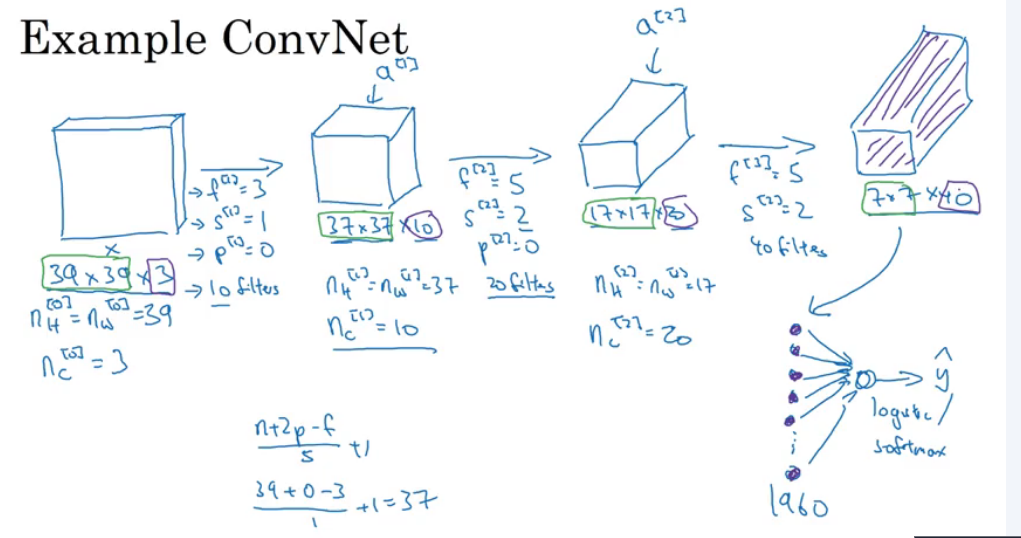

## Types of Layers 
- Convolutional layer
- Pooling layer
- Fully conected layer

## Pooling layer detail
- Max() or mean()

In [33]:
matriz = np.array([
    [1, 3, 2, 1],
    [2, 9, 1, 1],
    [1, 3, 2, 3],
    [5, 6, 1, 2]
], dtype=np.int32)

print(matriz.shape)  # (4, 4)
matriz

(4, 4)


array([[1, 3, 2, 1],
       [2, 9, 1, 1],
       [1, 3, 2, 3],
       [5, 6, 1, 2]], dtype=int32)

In [52]:
f = 2
stride = 2
pooling_matrix = np.zeros((f, f))

pooling_matrix[0, 0] = matriz[0:2, 0:2].max()
pooling_matrix[0, 1] = matriz[0:2, 2:4].max()
pooling_matrix[1, 0] = matriz[2:4, 0:2].max()
pooling_matrix[1, 1] = matriz[2:4, 2:4].max()
pooling_matrix

array([[9., 2.],
       [6., 3.]])

In [55]:
## forma generica

outH = (matriz.shape[0] - f) // stride + 1
outW = (matriz.shape[1] - f) // stride + 1
pooling_matrix = np.zeros((outH, outW))

for i in range(outH):
    for j in range(outW):
        janela = matriz[i*stride:i*stride+f, j*stride:j*stride+f]
        pooling_matrix[i, j] = janela.max()

pooling_matrix


array([[9., 2.],
       [6., 3.]])

## Final Example

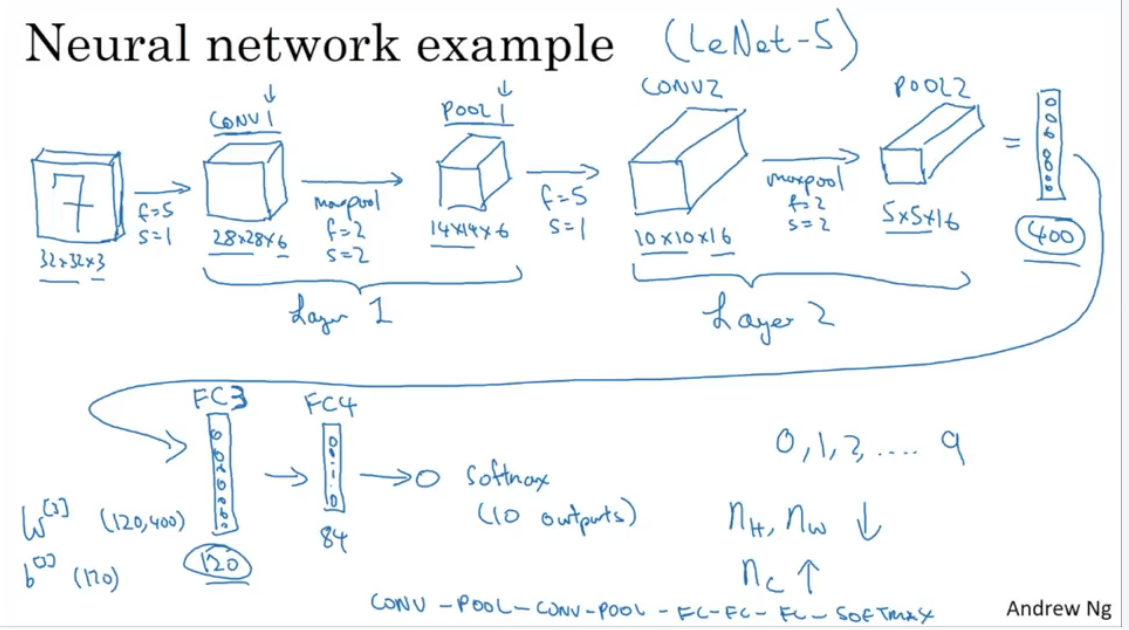

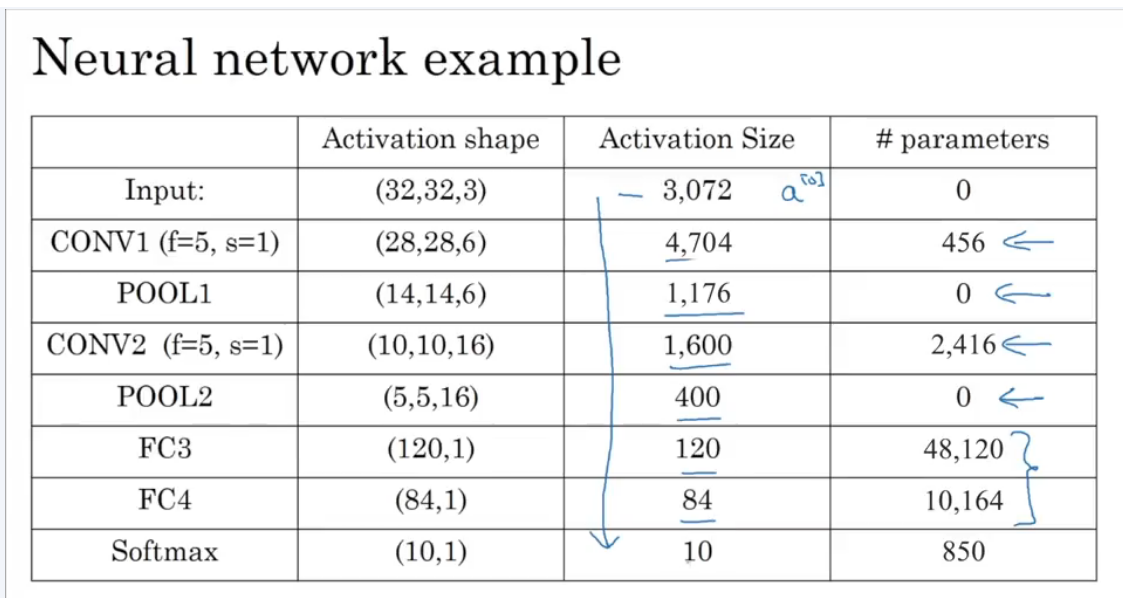